<a href="https://colab.research.google.com/github/Man10A/Churn-Prediction---Music-Application/blob/main/Multilayer_Perceptron_for_Images.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Assignment 1: Multilayer Perceptron for Images
**Name: Surendra Mantena**
**Course: 2026 Summer – Generative AI with Large Language Models (MSAI-630-B02)**

***

## Model Architecture

All three models share the same architecture and number of trainable parameters, with only the hidden layer activation function changed:

- **Input:** Flatten 28×28 = 784 features
- **Hidden Layer 1:** 200 neurons
- **Hidden Layer 2:** 150 neurons
- **Output Layer:** 10 neurons (softmax)
- **Total Parameters:** 188,660
- **Dataset:** Fashion-MNIST (60,000 training / 10,000 test images)
- **Optimizer:** Adam
- **Loss:** Sparse Categorical Crossentropy
- **Epochs:** 10

***

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Flatten, Dense, LeakyReLU
from tensorflow.keras.datasets import fashion_mnist

In [3]:
# Load Fashion-MNIST dataset
(x_train, y_train), (x_test, y_test) = fashion_mnist.load_data()

# Normalize pixel values to be between 0 and 1
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

print("Training data shape:", x_train.shape)
print("Test data shape:", x_test.shape)
print("Training labels shape:", y_train.shape)

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training data shape: (60000, 28, 28)
Test data shape: (10000, 28, 28)
Training labels shape: (60000,)


In [4]:
# Model 1 - ReLU
model_relu = Sequential([
    Flatten(input_shape=(28, 28)),
    Dense(200, activation='relu'),
    Dense(150, activation='relu'),
    Dense(10, activation='softmax')
])

model_relu.compile(
    loss='sparse_categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

model_relu.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 200)            │       157,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 150)            │        30,150 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │         1,510 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 188,660 (736.95 KB)

 Trainable params: 188,660 (736.95 KB)

 Non-trainable params: 0 (0.00 B)

In [5]:
# Train Model 1 - ReLU
print("Training ReLU Model...")
history_relu = model_relu.fit(
    x_train, y_train,
    epochs=10,
    batch_size=32,
    validation_data=(x_test, y_test),
    verbose=1
)

# Evaluate
relu_loss, relu_acc = model_relu.evaluate(x_test, y_test, verbose=0)
print(f"\nReLU Test Accuracy: {relu_acc:.4f}")
print(f"ReLU Test Loss: {relu_loss:.4f}")

Training ReLU Model...
Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 5ms/step - accuracy: 0.8278 - loss: 0.4798 - val_accuracy: 0.8551 - val_loss: 0.4100
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.8672 - loss: 0.3608 - val_accuracy: 0.8610 - val_loss: 0.3808
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.8794 - loss: 0.3232 - val_accuracy: 0.8672 - val_loss: 0.3645
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.8861 - loss: 0.3005 - val_accuracy: 0.8678 - val_loss: 0.3654
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.8938 - loss: 0.2833 - val_accuracy: 0.8753 - val_loss: 0.3416
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.9010 - loss: 0.2683 - val_accuracy: 0.8832 - val_loss: 0.3309
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9037 - loss: 0.2558 - val_accuracy: 0.8846 - val_loss: 0.3299
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accura

In [6]:
# Model 2 - LeakyReLU
from tensorflow.keras.layers import Input

model_leaky = Sequential([
    Input(shape=(28, 28)),
    Flatten(),
    Dense(200),
    LeakyReLU(negative_slope=0.2),
    Dense(150),
    LeakyReLU(negative_slope=0.2),
    Dense(10, activation='softmax')
])

model_leaky.compile(
    loss='sparse_categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

model_leaky.summary()

print("\nTraining LeakyReLU Model...")
history_leaky = model_leaky.fit(
    x_train, y_train,
    epochs=10,
    batch_size=32,
    validation_data=(x_test, y_test),
    verbose=1
)

leaky_loss, leaky_acc = model_leaky.evaluate(x_test, y_test, verbose=0)
print(f"\nLeakyReLU Test Accuracy: {leaky_acc:.4f}")
print(f"LeakyReLU Test Loss: {leaky_loss:.4f}")

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_1 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 200)            │       157,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu (LeakyReLU)         │ (None, 200)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 150)            │        30,150 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_1 (LeakyReLU)       │ (None, 150)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │         1,510 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 188,660 (736.95 KB)

 Trainable params: 188,660 (736.95 KB)

 Non-trainable params: 0 (0.00 B)


Training LeakyReLU Model...
Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.8263 - loss: 0.4790 - val_accuracy: 0.8538 - val_loss: 0.4007
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.8654 - loss: 0.3670 - val_accuracy: 0.8597 - val_loss: 0.3864
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.8763 - loss: 0.3357 - val_accuracy: 0.8661 - val_loss: 0.3751
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.8827 - loss: 0.3177 - val_accuracy: 0.8615 - val_loss: 0.3786
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.8888 - loss: 0.2989 - val_accuracy: 0.8675 - val_loss: 0.3783
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.8934 - loss: 0.2846 - val_accuracy: 0.8794 - val_loss: 0.3333
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.8979 - loss: 0.2738 - val_accuracy: 0.8642 - val_loss: 0.3664
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - 

In [7]:
# Model 3 - Sigmoid
model_sigmoid = Sequential([
    Input(shape=(28, 28)),
    Flatten(),
    Dense(200, activation='sigmoid'),
    Dense(150, activation='sigmoid'),
    Dense(10, activation='softmax')
])

model_sigmoid.compile(
    loss='sparse_categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

model_sigmoid.summary()

print("\nTraining Sigmoid Model...")
history_sigmoid = model_sigmoid.fit(
    x_train, y_train,
    epochs=10,
    batch_size=32,
    validation_data=(x_test, y_test),
    verbose=1
)

sigmoid_loss, sigmoid_acc = model_sigmoid.evaluate(x_test, y_test, verbose=0)
print(f"\nSigmoid Test Accuracy: {sigmoid_acc:.4f}")
print(f"Sigmoid Test Loss: {sigmoid_loss:.4f}")

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_2 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 200)            │       157,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 150)            │        30,150 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 10)             │         1,510 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 188,660 (736.95 KB)

 Trainable params: 188,660 (736.95 KB)

 Non-trainable params: 0 (0.00 B)


Training Sigmoid Model...
Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.8050 - loss: 0.5536 - val_accuracy: 0.8436 - val_loss: 0.4297
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.8616 - loss: 0.3804 - val_accuracy: 0.8536 - val_loss: 0.4044
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.8738 - loss: 0.3448 - val_accuracy: 0.8672 - val_loss: 0.3672
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.8832 - loss: 0.3175 - val_accuracy: 0.8659 - val_loss: 0.3691
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.8873 - loss: 0.3027 - val_accuracy: 0.8746 - val_loss: 0.3491
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.8942 - loss: 0.2843 - val_accuracy: 0.8770 - val_loss: 0.3415
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9002 - loss: 0.2709 - val_accuracy: 0.8781 - val_loss: 0.3377
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - ac

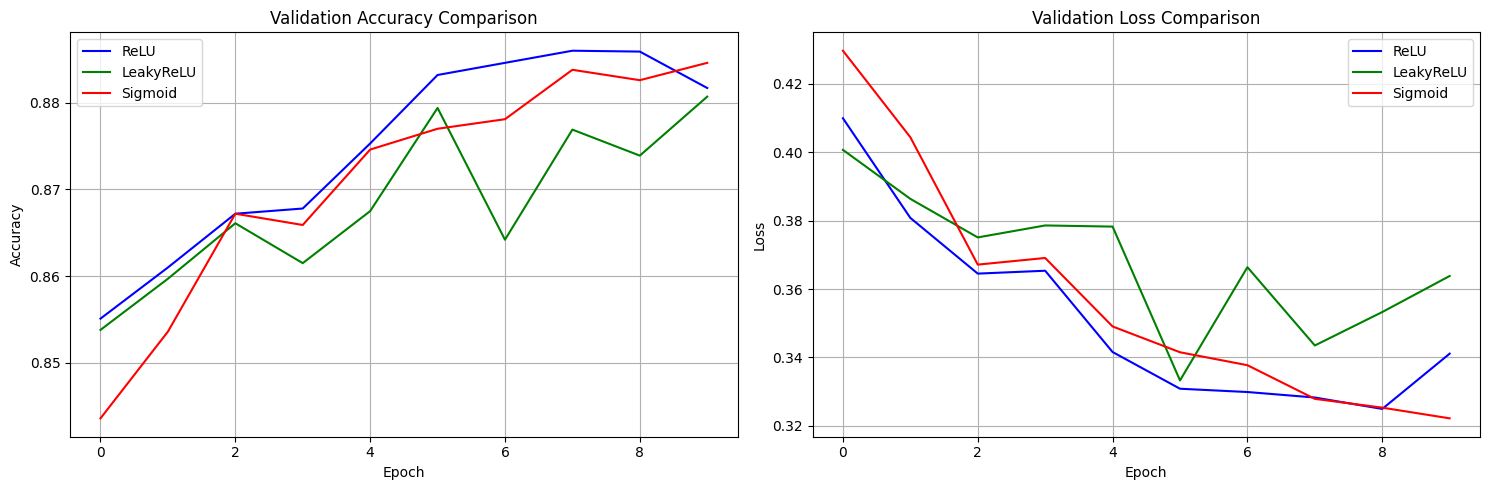

FINAL RESULTS SUMMARY
ReLU     - Test Accuracy: 0.8817 | Test Loss: 0.3411
LeakyReLU- Test Accuracy: 0.8807 | Test Loss: 0.3638
Sigmoid  - Test Accuracy: 0.8846 | Test Loss: 0.3222


In [8]:
# Plot Accuracy Comparison
plt.figure(figsize=(15, 5))

# Training Accuracy
plt.subplot(1, 2, 1)
plt.plot(history_relu.history['val_accuracy'], label='ReLU', color='blue')
plt.plot(history_leaky.history['val_accuracy'], label='LeakyReLU', color='green')
plt.plot(history_sigmoid.history['val_accuracy'], label='Sigmoid', color='red')
plt.title('Validation Accuracy Comparison')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

# Validation Loss
plt.subplot(1, 2, 2)
plt.plot(history_relu.history['val_loss'], label='ReLU', color='blue')
plt.plot(history_leaky.history['val_loss'], label='LeakyReLU', color='green')
plt.plot(history_sigmoid.history['val_loss'], label='Sigmoid', color='red')
plt.title('Validation Loss Comparison')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

# Final Summary
print("="*50)
print("FINAL RESULTS SUMMARY")
print("="*50)
print(f"ReLU     - Test Accuracy: {relu_acc:.4f} | Test Loss: {relu_loss:.4f}")
print(f"LeakyReLU- Test Accuracy: {leaky_acc:.4f} | Test Loss: {leaky_loss:.4f}")
print(f"Sigmoid  - Test Accuracy: {sigmoid_acc:.4f} | Test Loss: {sigmoid_loss:.4f}")

## Results Summary

| Model | Train Accuracy | Test Accuracy | Test Loss |
|-------|---------------|---------------|-----------|
| ReLU | 91.44% | 88.17% | 0.3411 |
| LeakyReLU | 90.77% | 88.07% | 0.3638 |
| **Sigmoid** | **90.98%** | **88.46%** | **0.3222** |



***

## Observations and Interpretation

### 1. ReLU

ReLU (Rectified Linear Unit) is defined as:

$$f(x) = \max(0, x)$$

ReLU converged quickly and steadily, reaching **88.17% test accuracy** with a test loss of **0.3411**. From epoch 1, training accuracy jumped to 82.78% and improved consistently each epoch. This is consistent with ReLU's well-known properties — it does not suffer from the vanishing gradient problem because its gradient is either 0 or 1, allowing efficient backpropagation through multiple layers. The gap between training accuracy (91.44%) and test accuracy (88.17%) indicates a small degree of overfitting, which is expected without regularization. ReLU is the standard baseline activation function for MLPs and performed as expected — fast, reliable convergence.

### 2. LeakyReLU

LeakyReLU is defined as:

$$f(x) = \begin{cases} x & \text{if } x > 0 \\ \alpha x & \text{if } x \leq 0 \end{cases}$$

where α = 0.2 in this experiment.

LeakyReLU achieved **88.07% test accuracy** with a test loss of **0.3638** — very close to ReLU but slightly lower on both metrics. LeakyReLU was designed to address the **dying ReLU problem**, where neurons that consistently receive negative inputs produce zero gradients and stop learning. By allowing a small negative slope (0.2), LeakyReLU ensures all neurons continue to receive gradient signal. However, on this relatively shallow 2-layer network trained on Fashion-MNIST, the dying ReLU problem is not severe enough to meaningfully differentiate the two. The validation loss of LeakyReLU showed slightly more fluctuation across epochs compared to ReLU, suggesting marginally less stable convergence on this task.

### 3. Sigmoid

Sigmoid is defined as:

$$f(x) = \frac{1}{1 + e^{-x}}$$

Sigmoid produced the **best test accuracy (88.46%)** and the **lowest test loss (0.3222)** among all three models — a result that is initially surprising given that sigmoid is generally considered less suitable for deep networks due to the vanishing gradient problem. However, this result makes sense in context: this is a **shallow 2-layer network**, not a deep one. With only two hidden layers, the gradient does not need to travel far during backpropagation, so the vanishing gradient effect is minimal. Furthermore, sigmoid's smooth, bounded output (0 to 1) acts as a natural regularizer, which may explain the lower test loss and slightly better generalization compared to ReLU and LeakyReLU.

Notably, sigmoid started with the lowest epoch 1 accuracy (80.50%) compared to ReLU (82.78%) and LeakyReLU (82.63%), confirming that it converges more slowly in early training. However, by epoch 10, it caught up and surpassed both, achieving the lowest validation loss of 0.3222.

***

## Key Takeaways

**1. All three models performed comparably** — within 0.4% test accuracy of each other — because the network is shallow (2 hidden layers) and the task is relatively straightforward. The differences in activation function behavior become more pronounced in deeper architectures.

**2. ReLU converged fastest** in early epochs, which is its primary advantage in practice — it reaches good performance quickly and is computationally efficient.

**3. LeakyReLU performed similarly to ReLU** with slightly higher loss, suggesting that the dying ReLU problem does not significantly impact this particular architecture and dataset.

**4. Sigmoid generalized best** in this specific experiment due to the shallow architecture limiting the vanishing gradient effect. Its bounded output provided a mild regularizing effect that resulted in the lowest test loss. This would not hold for deeper networks where vanishing gradients would significantly slow or prevent learning.

**5. The practical recommendation** for image classification tasks remains ReLU or its variants for deeper networks, despite sigmoid's marginal advantage here. ReLU's computational simplicity and resistance to vanishing gradients make it the preferred choice as network depth increases.

***

## References

Chollet, F. (2021). *Deep learning with Python* (2nd ed.). Manning Publications.

Foster, D. (2023). *Generative deep learning* (2nd ed.). O'Reilly Media.

Goodfellow, I., Bengio, Y., & Courville, A. (2016). *Deep Learning*. MIT Press.